<a href="https://colab.research.google.com/github/rootjihn/rootjihn.github.io/blob/main/260317_%EC%84%A0%ED%98%95%ED%9A%8C%EA%B7%80_%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1%ED%9A%8C%EA%B7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 머신러닝
## 정의
1. 데이터 기반으로 최적의 모델을 계산해서 완성합니다.
2. 이를 활용해서 새로운 데이터를 예측하거나 분류할 수 있게 하는 방법입니다.

## 모델이란?
- 모델은 수식입니다.
- 모델은 입력 데이터와 출력 데이터의 관계를 수식으로 표현한 함수.

x: 입력값
f: 모델
y hat: 모델 예측 결과값

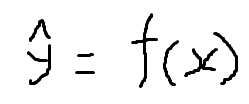

- Seaborn 에서 기본적으로 제공하는 Tips 데이터셋이 있습니다. 미국 레스토랑에서 사람들에게 받은 가격별 팁 데이터셋
- 선형 회귀는 "추세선" 을 찾아내는 머신러닝 모델
- 다음 차트와 같이 추세선을 그리는 수식이 "선형회귀모델"이 됩니다.

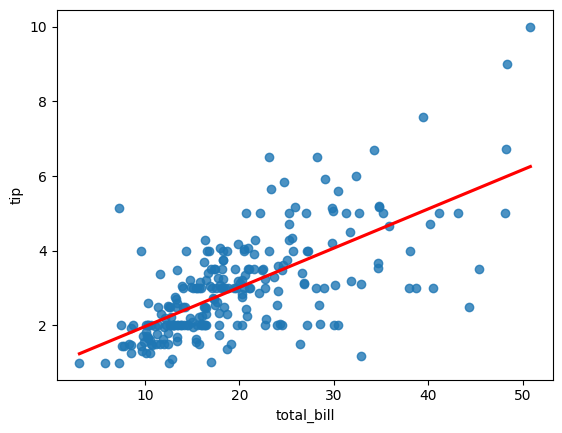

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 예시 데이터는 Tips
# https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv
tips = sns.load_dataset("tips")

# 모델 예시 (선형 회귀 모델)
# reg plot : 추세선을 그려주는 기능을 가지고 있습니다.

sns.regplot(x="total_bill", y="tip", data=tips, ci=None, line_kws={"color": "red"})
print()

## 학습과 추론?
- 추세선을 만들어내면 (모델을 만들어내면), 예측을 할수 있다.
- 모델을 만드는 과정을 "학습"이라고 합니다.
- 만든 모델을 가지고 예측하는 것을 "추론" 이라고 합니다.

## 머신러닝의 정의 다시 살펴보기
### 머신러닝의 정의
- 데이터를 기반으로 최적의 모델을 계산하여 완성합니다.
- 이를 활용해서 새로운 데이터를 예측하거나, 분류할 수 있게 하는 방법
### 머신러닝이 무엇인지 이해할 수 있겠죠?
- 참고로 LLM 에서 사용되는 신경망도 머신러닝의 일종입니다.

---

# 2. 선형 회귀 모델을 이해해보자.

## 선형 회귀 모델을 피쳐(Feature)의 추세선 or 추세면 입니다.
- 피쳐라고 하면 대상에서 값으로 표현하면서 모델에 입력되는 변수를 말합니다.
- 사람이 대상이면 "키, 몸무게, 나이" 이런 값들이 피쳐라고 할 수 있습니다.

## 선형회귀 모델을 만드는 방법을 생각해 보자.
- 선형 회귀 모델을 피쳐가 1개면 무조건 선, 2개면 면입니다.
- 피쳐 2개는 머리가 아프니, 1개만 생각해 보자.
- 선이면 직선의 방정식으로 직선의 방정식으로 이루어진다.
- $\hat{y}=ax+b$
- 목표는 "점들과 떨어져 있는 거리의 합이 최소"인 선을 찾아내는 것, a b 값을 찾아내면 된다.
- 실제 y값과 예측된 y값의 차이를 오차(Error)라고 합니다.
- 각 점별로 오차의 합이 최소가 되는 직선을 찾으면 최고의 추세선이 나옵니다.

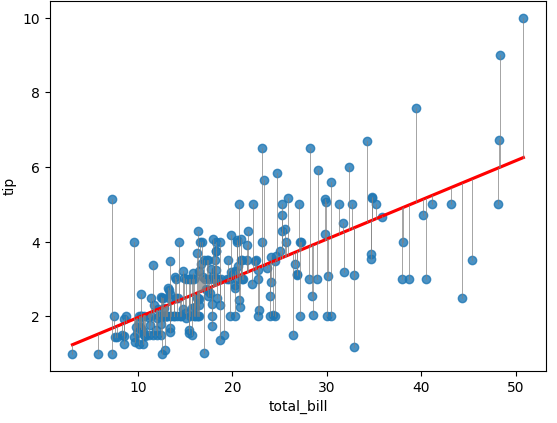

- a, b 값을 2중 for 문을 돌리면서, "오차의 합"이 최소가 되는 a, b를 쉽게 찾을수 있다.
- 이러한 방법을 Grid Search 라고 합니다. (실무에서 잘 쓰지는 않습니다)

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns

# 샘플 데이터
tips = sns.load_dataset("tips")
X = tips["total_bill"].values
Y = tips["tip"].values

# 검색 범위 설정
a_values = np.linspace(0, 2, 100) #기울기 후보를 0~2 사이 100개
b_values = np.linspace(0, 5, 100) #절편 후보를 0~5 사이 100개

best_a, best_b = None, None
min_error = float("inf")

#2중 for문으로 Grid Search
for a in a_values:
  for b in b_values:
    #예측하기
    y_hat = a * X + b #직선 방정식으로 y 예측값을 한꺼번에 계산

    error = np.sum(np.abs(Y - y_hat)) #Error 계산 = 오차의 합

    if error < min_error:
      min_error = error
      best_a, best_b = a, b

print("최적의 기울기 a:", best_a)
print("최적의 절편 b:", best_b)
print("최소 오차의 합:", min_error)

최적의 기울기 a: 0.12121212121212122
최적의 절편 b: 0.5555555555555556
최소 오차의 합: 179.96868686868686


## 추세선을 잘 그렸는지 확인

Text(0, 0.5, 'Tips')

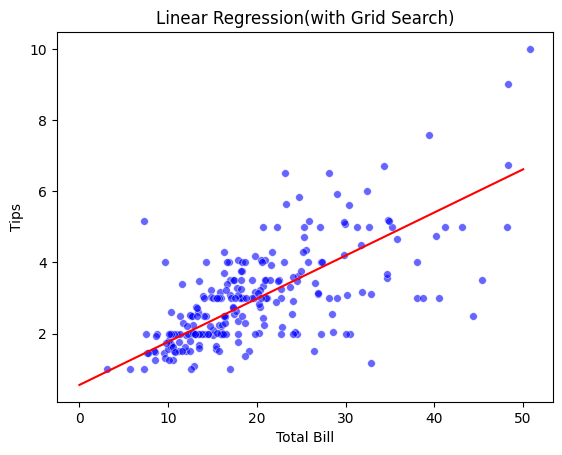

In [19]:
sns.scatterplot(x=X, y=Y, s=30, color="blue", alpha=0.6) #s : 점의 크기

#우리가 찾은 회귀선(빨간색)
x_line = np.linspace(0,50,100)
y_line = best_a * x_line + best_b

plt.title("Linear Regression(with Grid Search)")
plt.plot(x_line,y_line,color="red")
plt.xlabel("Total Bill")
plt.ylabel("Tips")

---

# 3. MAE (Mean Absolute Error)

- 방금은 오차의 합이 최소가 되는 것을 구했습니다.
- 오차의 합을 기준으로 하면 좋은 a, b 를 구할 수 있습니다.
- 하지만 오차의 합 값 자체는 의미가 없습니다.
- 데이터 양이 많아지면 값이 커지기 때문입니다.
- 그래서 오차의 평균을 사용합니다
- 오차의 평균은 데이터가 많던 적던, 예측 모델과 실제 값들의 차이를 수치로 잘 설명 할 수 있습니다.
- 평균은 np.mean() 함수를 쓰면 쉽게 구할 수 있습니다.

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns

# 샘플 데이터
tips = sns.load_dataset("tips")
X = tips["total_bill"].values
Y = tips["tip"].values

# 검색 범위 설정
a_values = np.linspace(0, 2, 100) #기울기 후보를 0~2 사이 100개
b_values = np.linspace(0, 5, 100) #절편 후보를 0~5 사이 100개

best_a, best_b = None, None
min_error = float("inf")

#2중 for문으로 Grid Search
for a in a_values:
  for b in b_values:
    #예측하기
    y_hat = a * X + b #직선 방정식으로 y 예측값을 한꺼번에 계산

    #error = np.sum(np.abs(Y - y_hat)) #Error 계산 = 오차의 합

    error = np.mean(np.abs(Y - y_hat))

    if error < min_error:
      min_error = error
      best_a, best_b = a, b

print("최적의 기울기 a:", best_a)
print("최적의 절편 b:", best_b)
print("최소 오차의 평균:", min_error)

최적의 기울기 a: 0.12121212121212122
최적의 절편 b: 0.5555555555555556
최소 오차의 평균: 0.7375765855274051


- 크게 결과는 바뀐건 없지만, 여기서 구한 오차의 평균 0.73 이라는 수치는 의미가 있습니다.
- 만든 모델이 실제 값과 얼마나 차이가 있는지를 표현할 수 있습니다.

---
# 4. MSE (Mean square Error)
- MAE는 오차 값에 적절히 값이 반영되었습니다.
- 오차가 크게 발생하면, 아주 큰 에러가 발생을 했다!! 라고 강조하고 싶어졌습니다.
- 그래서 오차의 제곱을 하면, 오차 값을 크게 반응하도록 만들어 보겠다.

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns

# 샘플 데이터
tips = sns.load_dataset("tips")
X = tips["total_bill"].values
Y = tips["tip"].values

# 검색 범위 설정
a_values = np.linspace(0, 2, 100) #기울기 후보를 0~2 사이 100개
b_values = np.linspace(0, 5, 100) #절편 후보를 0~5 사이 100개

best_a, best_b = None, None
min_error = float("inf")

#2중 for문으로 Grid Search
for a in a_values:
  for b in b_values:
    #예측하기
    y_hat = a * X + b #직선 방정식으로 y 예측값을 한꺼번에 계산

    #error = np.sum(np.abs(Y - y_hat)) #Error 계산 = 오차의 합
    #error = np.mean(np.abs(Y - y_hat)) #오차의 평균 MAE
    error = np.mean((Y-y_hat)**2) #오차 제곱의 평균 MSE


    if error < min_error:
      min_error = error
      best_a, best_b = a, b

print("최적의 기울기 a:", best_a)
print("최적의 절편 b:", best_b)
print("최소 오차 제곱의 평균:", min_error)

최적의 기울기 a: 0.10101010101010102
최적의 절편 b: 1.0101010101010102
최소 오차 제곱의 평균: 1.0373996209821346


Text(0, 0.5, 'Tips')

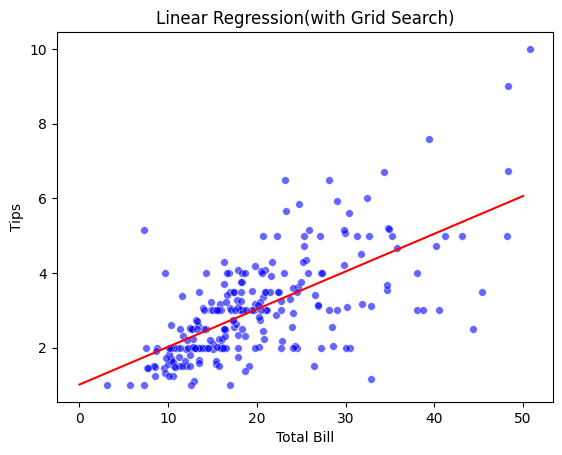

In [25]:
sns.scatterplot(x=X, y=Y, s=30, color="blue", alpha=0.6) #s : 점의 크기

#우리가 찾은 회귀선(빨간색)
x_line = np.linspace(0,50,100)
y_line = best_a * x_line + best_b

plt.title("Linear Regression(with Grid Search)")
plt.plot(x_line,y_line,color="red")
plt.xlabel("Total Bill")
plt.ylabel("Tips")

- 머신러닝 학자들은 MSE를 가장 흔하게 사용합니다.
- MSE 기억하기!!

---
# 5. 정규방정식
- 지금까지 우리는 2중 for문을 돌려서 좋은 a, b를 찾아냈다
- 더 좋은 방식이 있다면?
- MSE가 최소가 되는 a, b를 미분 방정식으로 한방에 구할 수 있습니다.
- 2중 for문 없이요!!

In [26]:
import numpy as np
import seaborn as sns

# 샘플 데이터
tips = sns.load_dataset("tips")
X = tips["total_bill"].values.reshape(-1, 1) #세로로 긴 행렬을 만들어 준다. (n,1) 형태로 변경
Y = tips["tip"].values.reshape(-1, 1) #세로로 긴 행렬을 만들어 준다. (n,1) 형태로 변경

# X 행렬 앞에 [1]을 추가
X_b = np.c_[np.ones((X.shape[0], 1)), X] # [[1,x1], [1,x2] ...]

# 정규방정식 계산
b, a = np.linalg.inv(X_b.T @ X_b) @ (X_b.T) @ (Y)

print("절편 b:", b)
print("기울기 a:", a)

절편 b: [0.92026961]
기울기 a: [0.10502452]


- Grid Search 보다 MSE 값이 작게 나오는 최고의 a, b 값을 한방에 계산했습니다.

In [28]:
y_hat = a * X + b

#MSE 계산
mse = np.mean((Y-y_hat) ** 2)
print("MSE:", mse)

MSE: 1.036019442011377


- 정규방정식으로 구한 a, b 값으로 선형 회귀 모델 그림
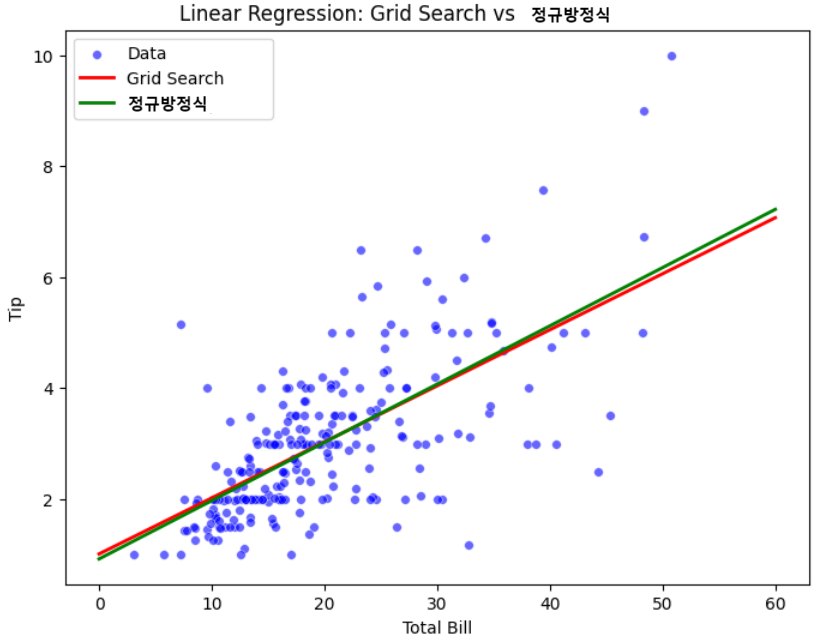

---
# 6. 정규방정식의 단점
- 역행렬 정규방정식에 들어갑니다.
- 이걸 GPU가 계산하는데 되게 느립니다.
- 어떤 경우는 역행렬을 구할 수 없는 경우도 있음
- 피쳐가 늘어날수록 연산이 불가능할 정도로 연산량과 메모리 사용량이 많아진다.

## 그럼 언제 사용하나
- 데이터가 적을때만 사용, 많아지면 큰 의미가 없음

## 그래서 우리는..
- 역행렬을 구하기 힘들고, 구할 수 없다면, 유사 역행렬을 사용하는 SVD 기법
- SVD는 역행렬 문제는 해결이 가능하다.
- 그치만 피쳐가 늘어날 수록 메모리 사용량은 여전히 힘들어요.
- 그래서 Gradient Descent(GD) 방법을 사용합니다.
- Gradient Descent가 가장 중요합니다.
- 머신러닝 전반적으로, 특히 신경망에서도 가장 널리 쓰이는 방법

---
# 7. Gradient Descent(GD)
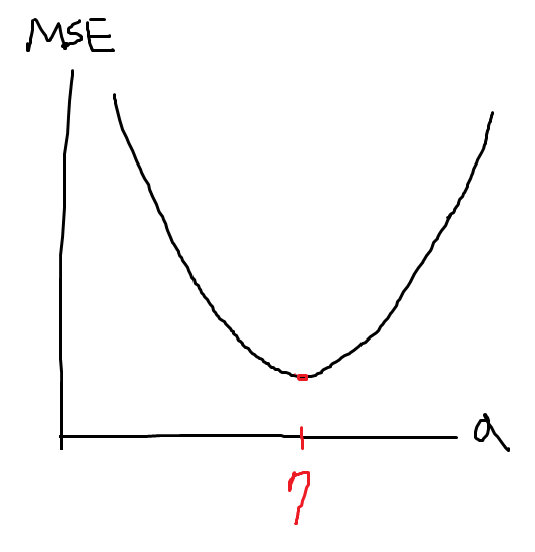

- a 값이 7이 될때 MSE가 최소값이 됩니다.
- 전체 데이터를 이용하여 수식을 만들면, a가 7일때 최솟값이라는걸 알 수 있습니다.(정규방정식)
- 우리의 목적은 전체 데이터를 사용하지 않고
- 최소한의 데이터만 살펴보는 방법으로 a=7일때 최솟값인 것을 찾아야 합니다.
- 점프를 하게 되면, 되게 적은 횟수로 MSE가 작은 좋은 a값을 찾을 수 있습니다.
- 모델은 반드시 주어지는 데이터에서 MSE가 최소가 되는 값일 필요는 없습니다.
- 처음 보는 데이터에도 잘 작동하기 위해선 적절한 MSE가 적은 값이 필요합니다.


Epoch 0, MSE=1247.9720, a=-0.6870, b=-0.7125
Epoch 100, MSE=1.4498, a=0.1711, b=-0.6498
Epoch 200, MSE=1.4361, a=0.1700, b=-0.6237
Epoch 300, MSE=1.4230, a=0.1689, b=-0.5981
Epoch 400, MSE=1.4102, a=0.1678, b=-0.5729
Epoch 500, MSE=1.3979, a=0.1668, b=-0.5481
Epoch 600, MSE=1.3860, a=0.1658, b=-0.5237
Epoch 700, MSE=1.3744, a=0.1648, b=-0.4997
Epoch 800, MSE=1.3633, a=0.1638, b=-0.4761
Epoch 900, MSE=1.3525, a=0.1628, b=-0.4529



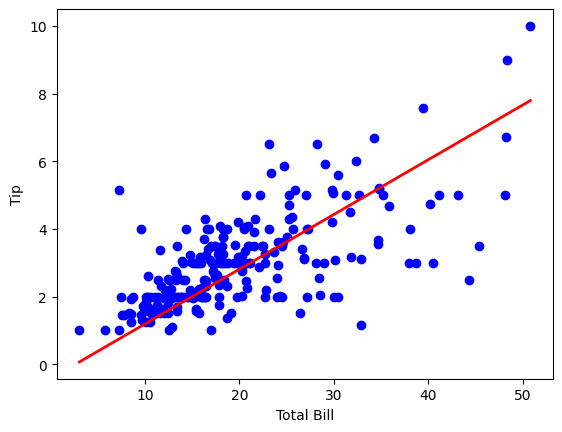

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 샘플 데이터 (Seaborn tips dataset)
tips = sns.load_dataset("tips")
X = tips["total_bill"].values
y = tips["tip"].values

# 파라미터 초기화 (a: 기울기, b: 절편)
a = np.random.randn()
b = np.random.randn()

# 하이퍼파라미터 (우리(개발자)의 경험으로 정한 값을 하이퍼파라미터라고 합니다.)
lr = 0.001 # 학습률 (점프 거리 조율)
epochs = 1000 # 몇 번 반복 학습할지 (점프 횟수 조율)

# Gradient Descent 학습 (Batch Gradient Descent 라고도 합니다.)
for epoch in range(epochs):
    # 모든 데이터에 대한 예측
    y_hat = a * X + b

    # 오차
    error = y_hat - y

    # MSE 수식을 미분하고 난 뒤, 수식을 정리한 결과 (수식 정리는 생략)
    # 여기서 기울기를 계산함
    grad_a = np.mean(error * X)
    grad_b = np.mean(error)

    # 파라미터 업데이트 (한 에폭에 단 1번, 점프!!)
    a -= lr * grad_a
    b -= lr * grad_b

    # 학습 상황 출력
    if epoch % 100 == 0:
        mse = np.mean((y - y_hat)**2)
        print(f"Epoch {epoch}, MSE={mse:.4f}, a={a:.4f}, b={b:.4f}")


# 학습된 직선 그리기
plt.scatter(X, y, color="blue", label="Data")
x_line = np.linspace(X.min(), X.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, color="red", linewidth=2, label="Batch GD Line")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
print()

---
# 8. 더 똑똑한 경사 하강법 --> 아담
- 기존에는 학습률(lr) 만큼 무지성 점프를 했습니다.
- 그러다보니 좋은 a, b를 못찾고 학습이 안되는 현상이 나옵니다.

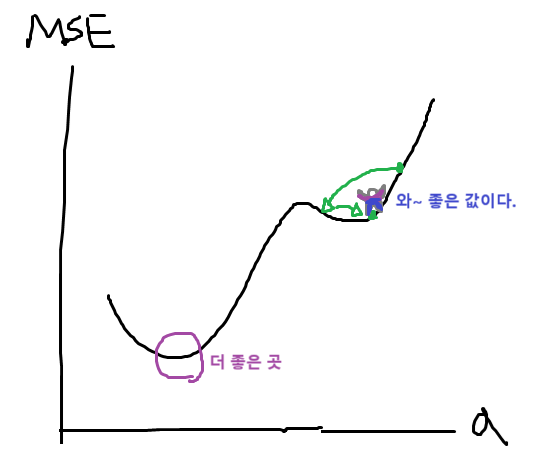

- 위와 같은 포인트를 지역 최소점(Local Minimum)에 갇혔다 라고 표현합니다.

## 그래서 나온게 아담이라는 경사 하강법, 더 똑똑한 점프를 하는 아이디어
- 이전 점프 방향과 동일한 방향으로 점프 몇번 더 해본다(관성)
- 이전 점프 방향과 방향이 동일한 방향이었다면 좀 더 크게 점프 해본다.
- 왔다 갔다 하는 부분은 점프 거리를 조금씩 줄여본다.(학습률 조율)


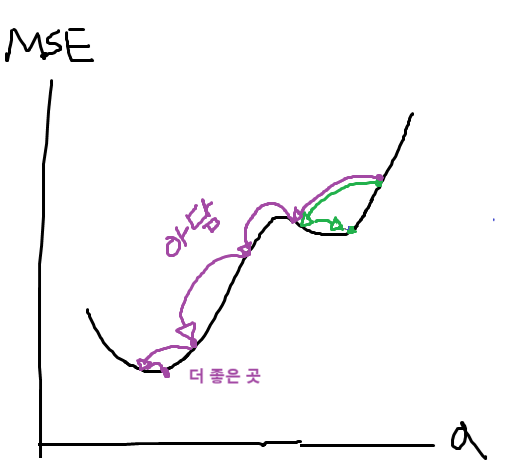

- 신경망에서는 기본 GD 보다는 GD의 업그레이드 버전인 Adam을 더 많이 사용합니다!
- 정확한 용어 Adam Optimizer 라고 합니다.
- 수식은 생략합니다.

---
# 9. 선형 회귀 (Linear Regression) 정리

- 추세선을 모델은 추세선 수식을 만드는 것으로 기억하면 됩니다.
- 수식이 만들어지면, 새로운 값에 대해 예측할 수 있습니다. 이걸 머신러닝이라고 합니다.


## 선형 회귀 모델을 만드는 방법은 크게 두가지 입니다.

### 정규 방정식
- 한방에 빵 하고 $y=ax+b$의 값을 계산합니다.
- MSE가 최소인 값을 한번에 계산
- 단점은 계산량이 많아서, 피쳐가 많으면 계산이 안됩니다.

### Gradient Decent(경사하강법, GD)
- MSE가 최소인 곳을 점프 점프 하면서 찾아갑니다.
- 계산량이 적어서 피쳐가 많아도 빠르게 $y=ax+b$의 a, b의 값을 찾아낼 수 있습니다.
- Local Minimum에 빠질 수 있어서, 아담같은 경사하강법을 씁니다.

---
# 10. 로지스틱 회귀(Logistic Regression)

- 회귀라는 단어는 수를 예측한다는 말
- 로지스틱 회귀는 실제로는 분류 기법입니다.
- 입력 값이 두 범주 중에 한 범주에 속할 확률을 예측하는 기법

## 이진분류 문제의 예시
- 공부시간을 넣으면, 합격인지 아닌지 확률을 알려주는 모델
- 키워드를 넣으면, 스팸 메일인지 아닌지 확률을 알려주는 모델
- 병원에서 혈압, 콜레스테롤, 몸무게, 나이, 키를 넣으면 코로나에 걸릴 확률을 알려주는 모델

## 로지스틱 회귀로 완성된 모델을 이해하기
- 공부시간에 따른 시험 합격 여부를 가지고 설명합니다.


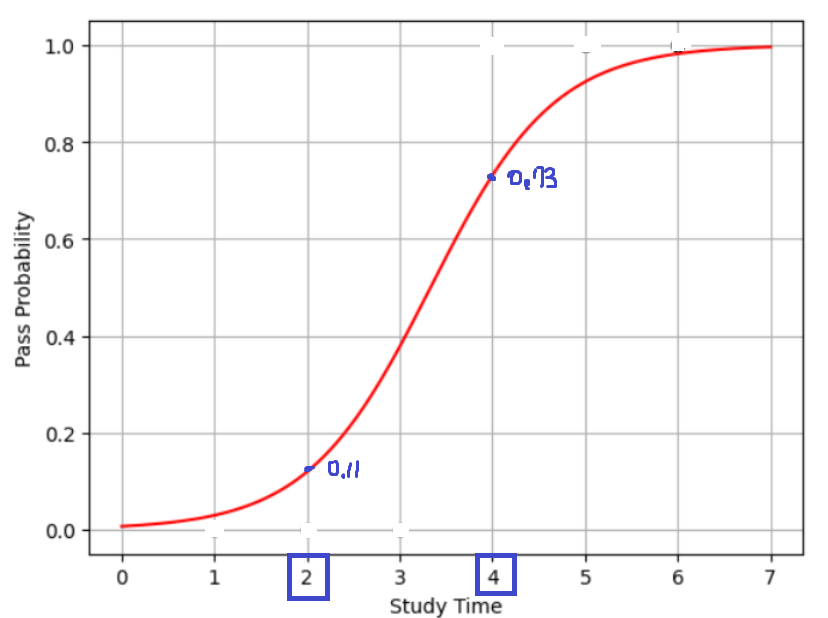

- 2시간 공부한 학생은 합격 확률이 0.11(11%)
- 4시간 공부한 학생은 합격 확률이 0.73(73%)

만약 우리가 이 모델을 만들 수 있다면
공부 시간에 따라 합격과 불합격 확률을 구할 수 있습니다.
이것을 우리는 이진 분류 모델이라고 합니다.



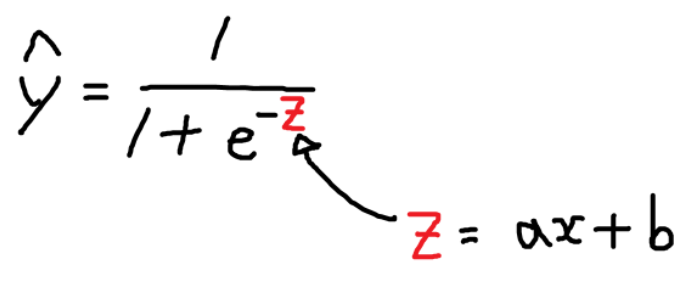

- 위 수식은 시그모이드 함수라고 합니다.
- 코드로 이해해 봅시다.

- 학습결과 a:1.5
- 학습결과 b:-5 라고 가정합니다.

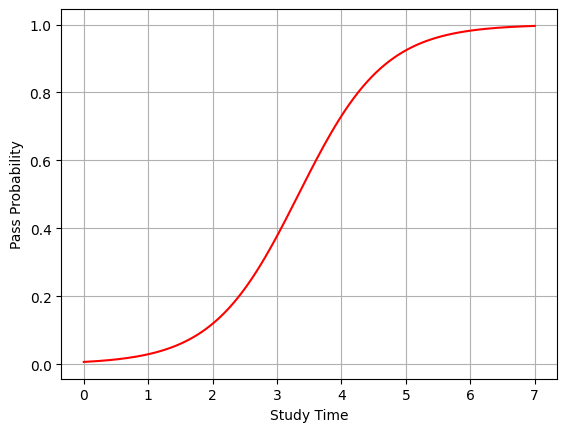

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# 시그모이드 함수 정의
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 학습이 다 완료 됐다고 가정한다. 학습 완료된 파라미터 결과는 (a, b)
a = 1.5
b = -5

# 모델을 이쁘게 그려보기 위한 X 값
X = np.linspace(0, 7, 200)

# 모델 예측 값
y_hat = sigmoid(a * X + b) # z = ax + b

plt.plot(X, y_hat, color="red")
plt.xlabel("Study Time")
plt.ylabel("Pass Probability")
plt.grid(True)
print()

## 우리가 학습을 통해 알아내야 하는 값은 바로 a, b입니다.
- 선형 회귀 문제는 $y=ax+b$에서 a, b를 알아내서 추세선을 만들어내는 문제
- 로지스틱 회귀 문제는 $y=sigmoid(ax+b)$에서 a, b를 알아내서 확률 곡선을 만들어 내는 문제


---
# 11. 로지스틱 회귀 문제에 Grid Search 적용하기
- 선형 회귀 문제처럼 2중 for문을 돌려서 최적의 a, b값을 알아보자


최적 기울기 a: 2.878787878787879
최적 절편 b: -10.0
최소 Loss값 (MSE): 0.010246529853078815



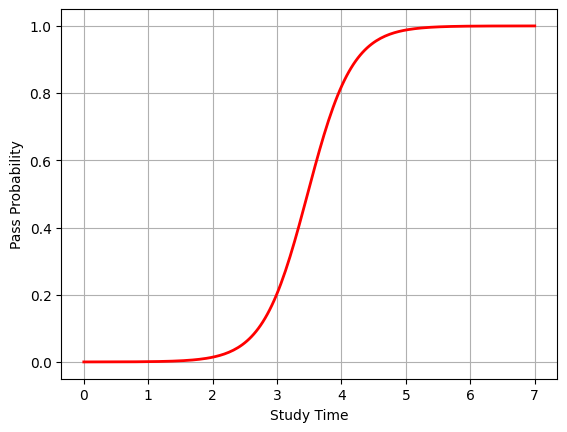

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 공부 시간 (X) 데이터
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10])

# 합격 여부 (y) 데이터, 1 이면 합격, 0 이면 탈락!
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

# 시그모이드 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 로스 함수
def get_loss(y, y_hat):
    return np.mean((y - y_hat)**2) #MSE

# 탐색 범위
a_values = np.linspace(0, 3, 100)
b_values = np.linspace(-10, 10, 100)

best_a, best_b = None, None
min_loss = float("inf")

# Grid Search
for a in a_values:
    for b in b_values:
        # X의 모든 데이터로 예측 값들 Y hat 만들기
        y_hat = sigmoid(a * X + b)

        # Error 계산
        loss = get_loss(y, y_hat)

        # Min 값 확인
        if loss < min_loss:
            min_loss = loss
            best_a, best_b = a, b

print("최적 기울기 a:", best_a)
print("최적 절편 b:", best_b)
print("최소 Loss값 (MSE):", min_loss)

# 최적 파라미터로 곡선 그리기
X_test = np.linspace(0, 7, 200)
y_prob = sigmoid(best_a * X_test + best_b)

plt.plot(X_test, y_prob, color="red", linewidth=2)
plt.xlabel("Study Time")
plt.ylabel("Pass Probability")
plt.grid(True)
print()


---
# 12. 크로스 엔트로피 적용하기
- Error을 구하는 공식을 Loss Function이라고 합니다.
- Loss Function을 구하기 위해 MSE를 써왔습니다.
- 그래서 MSE가 최소가 되는 a, b 값을 찾았습니다.
- MSE 맞췄을땐는 적은 패널티, 틀렸을때는 큰 패널티를 주면 잘 동작합니다.
- 그런데 소수점을 제곱하면, 오차를 크게 확대해서 보려고 하는데 더 작아지는 문제가 발생합니다.
- 따라서 작은 오차는 더 작게, 큰 오차는 아주 크게 확대를 해주는 크로스 엔트로피라는 Loss Function을 사용합니다.
- 로지스틱회귀 처럼 분류 문제에서는 Loss Function으로 크로스 엔트로피를 가장 많이 사용합니다.

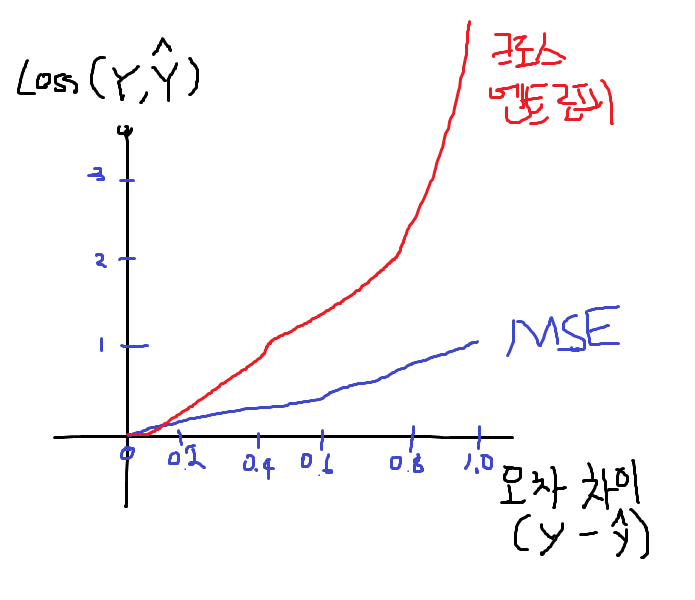

최적 기울기 a: 2.909090909090909
최적 절편 b: -10.0
최소 Loss값 (크로스엔트로피): 0.062280033955804455



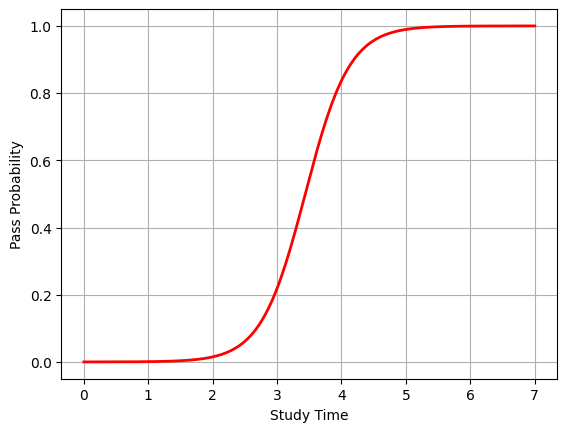

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# 공부 시간 (X) 데이터
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10])

# 합격 여부 (y) 데이터
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

# 시그모이드 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 로스 함수
def get_loss(y, y_hat):
    #return np.mean((y - y_hat)**2) #MSE

    # 크로스 엔트로피 <---- 이 부분 변경됨(수식 유도 설명은 생략!)
    eps = 1e-10
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

# 탐색 범위
a_values = np.linspace(0, 3, 100)
b_values = np.linspace(-10, 10, 100)

best_a, best_b = None, None
min_loss = float("inf")

# Grid Search
for a in a_values:
    for b in b_values:
        # 예측하기
        y_hat = sigmoid(a * X + b)

        # Error 계산
        loss = get_loss(y, y_hat)

        if loss < min_loss:
            min_loss = loss
            best_a, best_b = a, b

print("최적 기울기 a:", best_a)
print("최적 절편 b:", best_b)
print("최소 Loss값 (크로스엔트로피):", min_loss)

# 최적 파라미터로 곡선 그리기
X_test = np.linspace(0, 7, 200)
y_prob = sigmoid(best_a * X_test + best_b)

plt.plot(X_test, y_prob, color="red", linewidth=2)
plt.xlabel("Study Time")
plt.ylabel("Pass Probability")
plt.grid(True)
print()

---
# 13. Grid Search 대신에, 로지스틱 회귀의 좋은 학습 방법
- 크로스 엔트로피를 사용한 로지스틱 회귀 수식은 정규방정식으로 한방에 정답을 구할 수 있습니다.
- GD, Gradient Descent 경사 하강법으로 좋은 하강법으로 좋은 파라미터를 찾아낼 수 있습니다.
- 물론 Adam도 쓸 수 있습니다.
- 다음 코드는 GD 코드로 학습하는 코드입니다.

Epoch 0, Loss=0.4927, a=0.4628, b=-0.1585
Epoch 500, Loss=0.1919, a=1.1326, b=-3.5483
Epoch 1000, Loss=0.1389, a=1.5473, b=-5.1052
Epoch 1500, Loss=0.1141, a=1.8402, b=-6.1758
Epoch 2000, Loss=0.0988, a=2.0728, b=-7.0162
Epoch 2500, Loss=0.0881, a=2.2689, b=-7.7197
Epoch 3000, Loss=0.0800, a=2.4402, b=-8.3314
Epoch 3500, Loss=0.0736, a=2.5933, b=-8.8763
Epoch 4000, Loss=0.0684, a=2.7323, b=-9.3702
Epoch 4500, Loss=0.0639, a=2.8602, b=-9.8235

최적 기울기 a: 2.9786155185218623
최적 절편 b: -10.242717697389347
최종 Loss: 0.060115360098514155



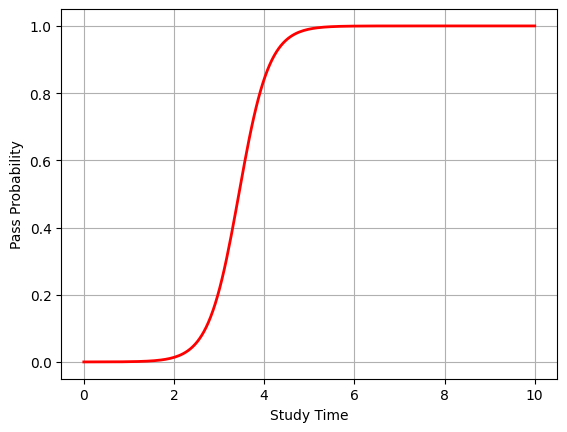

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# 공부 시간 (X), 합격 여부 (y)
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10])
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 하이퍼 파라미터 초기화
lr = 0.1  # 학습률
epochs = 5000

# a, b 초기값 세팅
np.random.seed(42)  # 재현성 고정
a = np.random.randn()  # 기울기
b = np.random.randn()  # 절편

# Gradient Descent
for epoch in range(epochs):
    # 예측
    y_hat = sigmoid(a * X + b)

    # Loss (Cross Entropy)
    eps = 1e-10
    loss = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

    # 기울기 계산
    error = y_hat - y
    grad_a = np.mean(error * X)
    grad_b = np.mean(error)

    # 파라미터 업데이트 (점프!)
    a -= lr * grad_a
    b -= lr * grad_b

    # Loss값 출력
    if epoch % 500 == 0:
      print(f"Epoch {epoch}, Loss={loss:.4f}, a={a:.4f}, b={b:.4f}")

# 학습 결과
print()
print("최적 기울기 a:", a)
print("최적 절편 b:", b)
print("최종 Loss:", loss)

# 시각화
X_test = np.linspace(0, 10, 200)
y_prob = sigmoid(a * X_test + b)

plt.plot(X_test, y_prob, color="red", linewidth=2)
plt.xlabel("Study Time")
plt.ylabel("Pass Probability")
plt.grid(True)
print()
